In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine

In [16]:
data = load_wine()

In [17]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Target'] = data.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  Targe

In [19]:
df['Target'].value_counts()

Target
1    71
0    59
2    48
Name: count, dtype: int64

In [25]:
## Dividing data in dependent and independent feature

#Independent features
X = pd.DataFrame(data.data, columns=data.feature_names)

#dependent feature
y = pd.DataFrame(data.target, columns=['Target'])

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [57]:
##Evaluation
print("Accuracy of model:", accuracy_score(y_test, y_pred), end="\n\n")
print("Classification Report:\n\n", classification_report(y_test, y_pred))

Accuracy of model: 0.9661016949152542

Classification Report:

               precision    recall  f1-score   support

           0       0.95      0.95      0.95        20
           1       0.96      1.00      0.98        24
           2       1.00      0.93      0.97        15

    accuracy                           0.97        59
   macro avg       0.97      0.96      0.97        59
weighted avg       0.97      0.97      0.97        59



[Text(0.5, 0.9, 'color_intensity <= 3.82\ngini = 0.66\nsamples = 119\nvalue = [39, 47, 33]\nclass = class_1'),
 Text(0.3, 0.7, 'ash <= 3.07\ngini = 0.089\nsamples = 43\nvalue = [2, 41, 0]\nclass = class_1'),
 Text(0.4, 0.8, 'True  '),
 Text(0.2, 0.5, 'proline <= 1010.0\ngini = 0.046\nsamples = 42\nvalue = [1, 41, 0]\nclass = class_1'),
 Text(0.1, 0.3, 'gini = 0.0\nsamples = 41\nvalue = [0, 41, 0]\nclass = class_1'),
 Text(0.3, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [1, 0, 0]\nclass = class_0'),
 Text(0.4, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0, 0]\nclass = class_0'),
 Text(0.7, 0.7, 'flavanoids <= 1.4\ngini = 0.568\nsamples = 76\nvalue = [37, 6, 33]\nclass = class_0'),
 Text(0.6, 0.8, '  False'),
 Text(0.6, 0.5, 'gini = 0.0\nsamples = 33\nvalue = [0, 0, 33]\nclass = class_2'),
 Text(0.8, 0.5, 'proline <= 724.5\ngini = 0.24\nsamples = 43\nvalue = [37, 6, 0]\nclass = class_0'),
 Text(0.7, 0.3, 'alcohol <= 13.145\ngini = 0.245\nsamples = 7\nvalue = [1, 6, 0]\nclass = class_1'),
 Tex

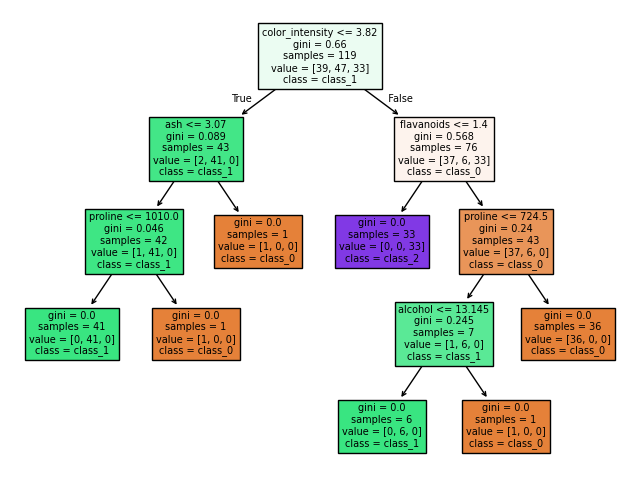

In [59]:
## Decision Tree
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plot_tree(model, feature_names=data.feature_names, class_names=data.target_names, filled=True)

In [60]:
# Confusion Matrxi
cm = confusion_matrix(y_test, y_pred)
cm

array([[19,  1,  0],
       [ 0, 24,  0],
       [ 1,  0, 14]])

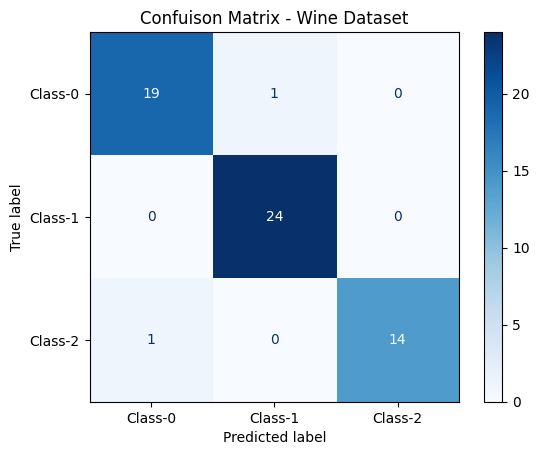

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Class-0", "Class-1", "Class-2"], cmap="Blues")
plt.title('Confuison Matrix - Wine Dataset')
plt.show()